## Аналітичне дослідження клієнтської поведінки за допомогою лінійної регресії

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("project1_df.csv")
df.head(3)

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi


In [13]:
df.shape  # розмірність

(55000, 13)

In [14]:
df.columns   # назви колонок

Index(['CID', 'TID', 'Gender', 'Age Group', 'Purchase Date',
       'Product Category', 'Discount Availed', 'Discount Name',
       'Discount Amount (INR)', 'Gross Amount', 'Net Amount',
       'Purchase Method', 'Location'],
      dtype='object')

In [15]:
df.info()   # типи даних

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [16]:
df.describe() # статистика по числових

,CID,TID,Discount Amount (INR),Gross Amount,Net Amount
count,55000.000000,5.500000e+04,55000.000000,55000.000000,55000.000000
mean,551245.593891,5.504740e+09,136.986796,3012.936606,2875.949810
std,260603.330337,2.594534e+09,165.375502,1718.431066,1726.127778
min,100009.000000,1.000163e+09,0.000000,136.454325,-351.119775
25%,323717.000000,3.252604e+09,0.000000,1562.111325,1429.551863
50%,550088.500000,5.498383e+09,0.000000,2954.266150,2814.910875
75%,776955.750000,7.747933e+09,274.115000,4342.221675,4211.407838
max,999996.000000,9.999393e+09,500.000000,8394.825600,8394.825600


In [17]:
df.isnull().sum() # Перевірка наявності пропущених значень у кожній колонці

CID                          0
TID                          0
Gender                       0
Age Group                    0
Purchase Date                0
Product Category             0
Discount Availed             0
Discount Name            27585
Discount Amount (INR)        0
Gross Amount                 0
Net Amount                   0
Purchase Method              0
Location                     0
dtype: int64

In [38]:
df["Discount Name"] = df["Discount Name"].fillna("No Discount")

In [39]:
df.isnull().sum() # Перевірка наявності пропущених значень у кожній колонці

CID                      0
TID                      0
Gender                   0
Age Group                0
Purchase Date            0
Product Category         0
Discount Availed         0
Discount Name            0
Discount Amount (INR)    0
Gross Amount             0
Net Amount               0
Purchase Method          0
Location                 0
Age_numeric              0
dtype: int64

In [18]:
df.duplicated().sum()  # Підрахунок загальної кількості повних дублікатів

np.int64(0)

In [19]:
df['Age Group'].unique()

array(['25-45', '60 and above', '18-25', '45-60', 'under 18'],
      dtype=object)

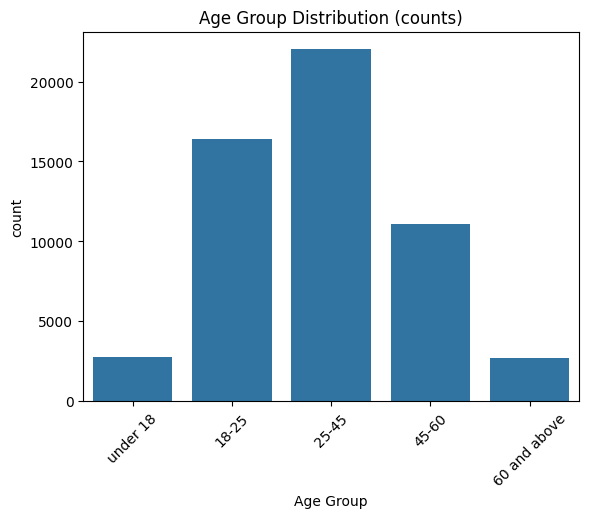

In [20]:
# Порядок груп (підстав свої назви, якщо вони інші)
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above']

sns.countplot(data=df, x='Age Group', order=age_order)
plt.title("Age Group Distribution (counts)")
plt.xticks(rotation=45)
plt.show()

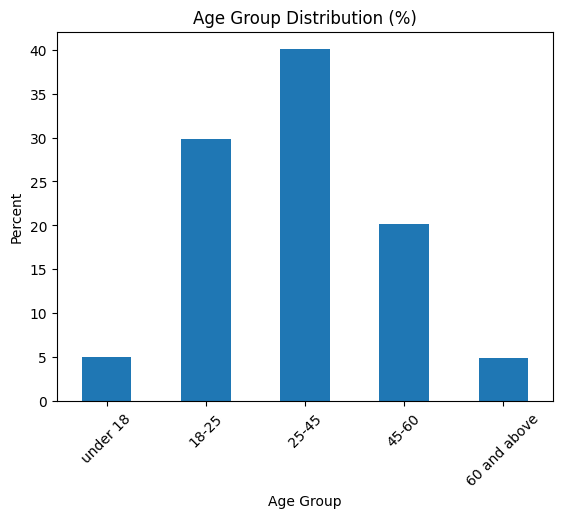

In [21]:
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above']

share = (
    df['Age Group']
    .value_counts(normalize=True)
    .reindex(age_order)
    * 100
)

share.plot(kind='bar')
plt.title("Age Group Distribution (%)")
plt.ylabel("Percent")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.groupby('Age Group')['Gross Amount'].mean().sort_index()

Age Group
18-25           2984.680912
25-45           3041.087756
45-60           2992.399477
60 and above    3026.011843
under 18        3026.510347
Name: Gross Amount, dtype: float64

In [23]:
df.groupby('Age Group')['Net Amount'].mean().sort_index()

Age Group
18-25           2848.573795
25-45           2904.739214
45-60           2853.368124
60 and above    2886.688814
under 18        2889.693613
Name: Net Amount, dtype: float64

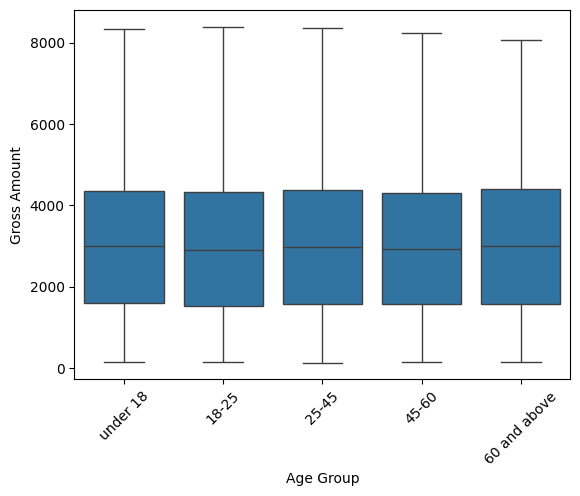

In [24]:
sns.boxplot(data=df, x='Age Group', y='Gross Amount', order=age_order)
plt.xticks(rotation=45)
plt.show()

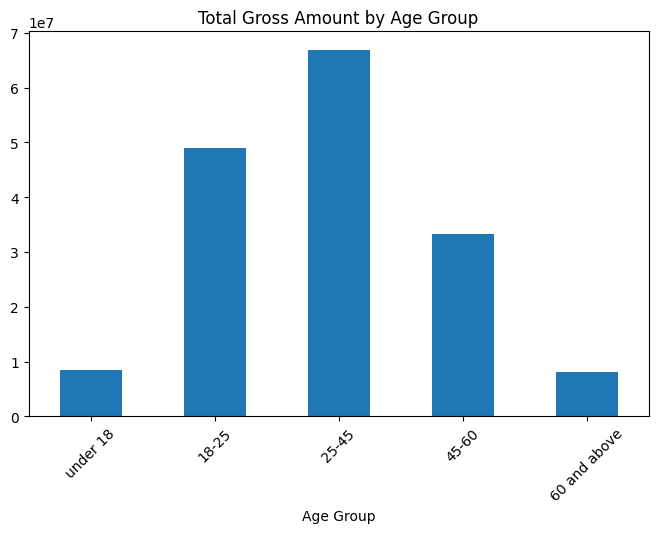

In [25]:
total_values = (
    df.groupby('Age Group')['Gross Amount']
      .sum()
      .reindex(age_order)
)

total_values.plot(kind='bar', figsize=(8,5))
plt.title("Total Gross Amount by Age Group")
plt.xticks(rotation=45)
plt.show()

In [26]:
mean_values = (
    df.groupby('Age Group')['Gross Amount']
      .mean()
      .reindex(age_order)
)

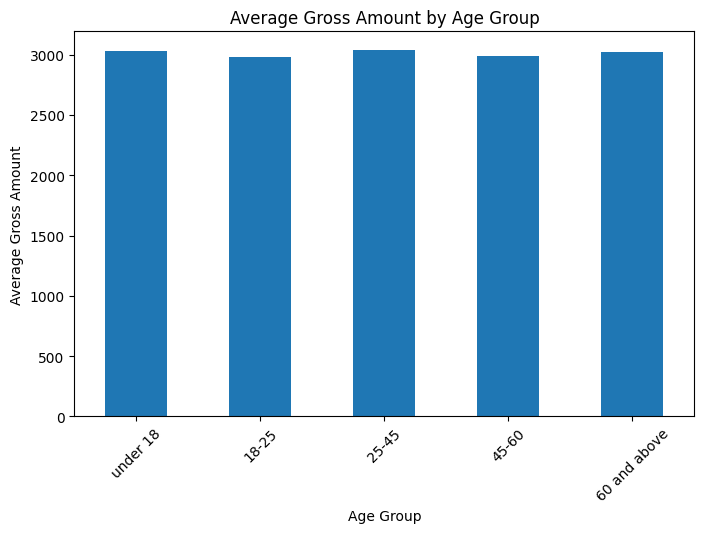

In [27]:

plt.figure(figsize=(8,5))

mean_values.plot(kind='bar')

plt.title("Average Gross Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Gross Amount")
plt.xticks(rotation=45)

plt.show()

## Model

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [45]:
required_columns = ['Gender', 'Age Group', 'Purchase Date',
       'Product Category', "Discount Name", 'Discount Availed', 'Discount Amount (INR)', 'Purchase Method', 'Location',"Gross Amount"] # позбавляємося ідентифікаторів та пустих значень
df = df[required_columns]

In [46]:
# X — ознаки (features), тобто вхідні дані для моделі
# Тут беремо:
# - ''Gender', 'Age Group', 'Purchase Date', 'Product Category', 'Discount Availed', 'Discount Amount (INR)', 'Gross Amount', 'Net Amount', 'Purchase Method', 'Location'
# Подвійні дужки [[...]] важливі: так виходить DataFrame (матриця ознак), що зручно для sklearn
X = df[["Gender", "Age Group", "Purchase Date",
       'Product Category', "Discount Name", 'Discount Availed', 'Purchase Method', 'Location']]
# target — назва цільової колонки (те, що ми хочемо передбачити)
# У датасеті Iris "species" — це вид квітки: setosa / versicolor / virginica
target = "Gross Amount"
# y — ціль (target), тобто правильні відповіді
# Це один стовпець Series, у якому записано вид квітки для кожного рядка
y = df[target]

In [47]:
# Розбиваємо дані на навчальну (train) і тестову (test) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # X — ознаки (features), y — ціль (target)
    test_size=0.25,       # 25% даних підуть у тестову вибірку,
                           # 75% залишаться для навчання моделі
    random_state=42       # фіксує випадковість розбиття,
                           # щоб результат був відтворюваним
)

In [48]:
X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")
X["purchase_year"] = X["Purchase Date"].dt.year
X["purchase_month"] = X["Purchase Date"].dt.month
X["purchase_dayofweek"] = X["Purchase Date"].dt.dayofweek
X = X.drop(columns=["Purchase Date"])

C:\Users\svetl\AppData\Local\Temp\ipykernel_35740\345371175.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")
C:\Users\svetl\AppData\Local\Temp\ipykernel_35740\345371175.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")
C:\Users\svetl\AppData\Local\Temp\ipykernel_35740\345371175.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [49]:
# щоб можна було порахувати вплив "старіння".
age_order = ['under 18', '18-25', '25-45', '45-60', '60 and above'] # Вкажи свої реальні категорії
X['Age Group'] = pd.Categorical(X['Age Group'], categories=age_order, ordered=True)
# Створюємо числовий стовпчик для регресії
X['Age_Numeric'] = X['Age Group'].cat.codes

In [50]:
# 4) Очистка від NaN
data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=["Gross Amount"])
y = data["Gross Amount"]

In [51]:
# 5) Списки колонок для пайплайну
# "Age_Numeric" тепер у числових, щоб модель бачила лінійну залежність
categorical_features = ["Gender", "Product Category", "Discount Availed", "Purchase Method", "Location"]
numeric_features = ["Age_Numeric", "purchase_year", "purchase_month", "purchase_dayofweek"]

In [52]:
# 6) Preprocess + model
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

In [53]:
# 7) Тренування
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [54]:
# 8) Аналіз результатів
y_pred = model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.4f}")

R2: 0.0477


In [55]:
# ОТРИМАННЯ ВІДПОВІДІ НА ВАШЕ ПИТАННЯ:
# Отримуємо коефіцієнт для Age_Numeric (він буде в кінці списку через passthrough)
coefs = model.named_steps['regressor'].coef_
age_impact = coefs[-4] # Останні 4 — це наші numeric_features, Age_Numeric — перший серед них

print(f"\nКоефіцієнт впливу вікової групи: {age_impact:.2f}")
print(f"При переході в наступну вікову групу (прибл. 10 років), витрати зміняться на: {age_impact:.2f}")

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



Коефіцієнт впливу вікової групи: 1.97
При переході в наступну вікову групу (прибл. 10 років), витрати зміняться на: 1.97
R2: 0.047745928889017186
MAE: 1420.459707810365


In [131]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Беремо X і y
X = df[["Gender", "Age Group", "Purchase Date",
        "Product Category", "Discount Availed", "Purchase Method", "Location"]].copy()
y = df["Gross Amount"].copy()

# 2) Перетворюємо Purchase Date -> datetime
X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")

# 3) Створюємо числові фічі з дати (це і є "заміна")
X["purchase_year"] = X["Purchase Date"].dt.year
X["purchase_month"] = X["Purchase Date"].dt.month
X["purchase_dayofweek"] = X["Purchase Date"].dt.dayofweek

# 4) Видаляємо оригінальну дату, бо вона вже не потрібна
X = X.drop(columns=["Purchase Date"])

# 5) Прибираємо рядки, де дата не розпарсилась або є NaN у важливих полях
data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=["Gross Amount"])
y = data["Gross Amount"]

# 6) Списки колонок
categorical_features = ["Gender", "Age Group", "Product Category",
                        "Discount Availed", "Purchase Method", "Location"]
numeric_features = ["purchase_year", "purchase_month", "purchase_dayofweek"]

# 7) Preprocess + model
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# 8) Train/test + fit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.04737453474948794
MAE: 1420.706040904046


C:\Users\svetl\AppData\Local\Temp\ipykernel_31860\2357849040.py:15: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  X["Purchase Date"] = pd.to_datetime(X["Purchase Date"], errors="coerce")
